In [1]:
from datasets import load_dataset

ds = load_dataset("electricsheepafrica/nigeria-education-admission-trends")

print(ds)

DatasetDict({
    train: Dataset({
        features: ['trend_id', 'school_id', 'academic_year', 'num_applications', 'num_accepted', 'num_enrolled', 'acceptance_rate', 'enrollment_rate', 'country'],
        num_rows: 100000
    })
})


In [2]:
import pandas as pd

df = ds["train"].to_pandas()

df.head()

,trend_id,school_id,academic_year,num_applications,num_accepted,num_enrolled,acceptance_rate,enrollment_rate,country
0,NGA_SCH_000000_ADM_2016,NGA_SCH_000000,2016/2017,NaN,455.0,NaN,0.500889,0.894923,Nigeria
1,NGA_SCH_000000_ADM_2017,NGA_SCH_000000,2017/2018,1094.0,531.0,392.0,0.485810,0.738999,Nigeria
2,NGA_SCH_000000_ADM_2018,NGA_SCH_000000,2018/2019,380.0,247.0,193.0,0.652587,0.783427,Nigeria
3,NGA_SCH_000000_ADM_2019,NGA_SCH_000000,2019/2020,921.0,727.0,512.0,0.789440,0.705146,Nigeria
4,NGA_SCH_000000_ADM_2020,NGA_SCH_000000,2020/2021,819.0,652.0,609.0,0.797099,0.934638,Nigeria


In [3]:
df.to_csv("education_admission_trends.csv", index=False)

In [4]:
print(df.columns)

Index(['trend_id', 'school_id', 'academic_year', 'num_applications',
       'num_accepted', 'num_enrolled', 'acceptance_rate', 'enrollment_rate',
       'country'],
      dtype='object')


In [5]:
print(df.shape)

(100000, 9)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   trend_id          100000 non-null  object 
 1   school_id         100000 non-null  object 
 2   academic_year     100000 non-null  object 
 3   num_applications  97918 non-null   float64
 4   num_accepted      98008 non-null   float64
 5   num_enrolled      98049 non-null   float64
 6   acceptance_rate   97970 non-null   float64
 7   enrollment_rate   97943 non-null   float64
 8   country           99010 non-null   object 
dtypes: float64(5), object(4)
memory usage: 6.9+ MB


In [7]:
missing_percent = df.isnull().sum()/len(df)*100
print(missing_percent)

trend_id            0.000
school_id           0.000
academic_year       0.000
num_applications    2.082
num_accepted        1.992
num_enrolled        1.951
acceptance_rate     2.030
enrollment_rate     2.057
country             0.990
dtype: float64


In [8]:
df.describe()

,num_applications,num_accepted,num_enrolled,acceptance_rate,enrollment_rate
count,97918.000000,98008.000000,98049.000000,97970.000000,97943.000000
mean,1026.541800,691.920404,570.648931,0.674818,0.825145
std,562.786113,422.899988,353.972551,0.159064,0.072268
min,50.000000,20.000000,14.000000,0.400011,0.700002
25%,539.000000,343.000000,280.000000,0.536442,0.762298
50%,1024.000000,652.000000,533.000000,0.675064,0.825402
75%,1514.000000,984.000000,810.000000,0.812253,0.887881
max,1999.000000,1895.000000,1773.000000,0.949994,0.949994


In [9]:
# Numeric columns ko median se fill karte hain
numeric_cols = ["num_applications","num_accepted","num_enrolled","acceptance_rate","enrollment_rate"]
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Country column ko forward fill
df["country"].fillna(method="ffill", inplace=True)

# Confirm
print(df.isnull().sum())

trend_id            0
school_id           0
academic_year       0
num_applications    0
num_accepted        0
num_enrolled        0
acceptance_rate     0
enrollment_rate     0
country             0
dtype: int64


C:\Users\Super\AppData\Local\Temp\ipykernel_5808\2205441303.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Super\AppData\Local\Temp\ipykernel_5808\2205441303.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [10]:
# '2016/2017' → 2016
df["year"] = df["academic_year"].str[:4].astype(int)

In [11]:
yearly_data = df.groupby("year")[["num_applications","num_accepted","num_enrolled"]].sum().reset_index()
yearly_data.head()

,year,num_applications,num_accepted,num_enrolled
0,2014,2097918.0,1408430.0,1155480.0
1,2015,4111072.0,2755453.0,2275542.0
2,2016,5959756.0,4032330.0,3327069.0
3,2017,7980293.0,5386364.0,4446231.0
4,2018,10076861.0,6793014.0,5595682.0


In [12]:
yearly_data["growth_rate"] = yearly_data["num_enrolled"].pct_change()*100

In [13]:
yearly_data["moving_avg"] = yearly_data["num_enrolled"].rolling(3).mean()

In [14]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = yearly_data["year"].values.reshape(-1,1)
y = yearly_data["num_enrolled"]

model = LinearRegression()
model.fit(X,y)

future_years = np.array(range(2025,2031)).reshape(-1,1)
predictions = model.predict(future_years)

forecast = pd.DataFrame({
    "year": range(2025,2031),
    "predicted_enrollment": predictions
})

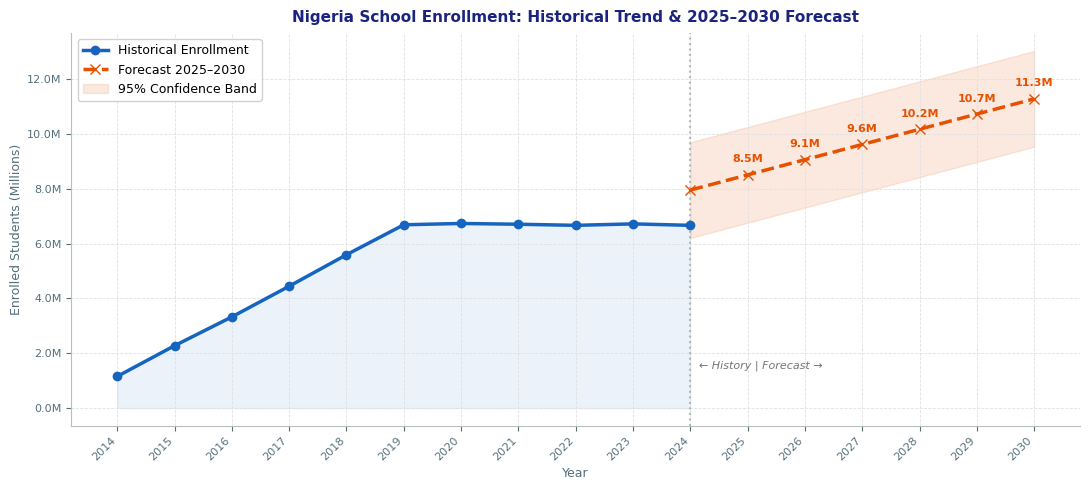

✅ Chart 1 saved: chart1_forecast_line.png


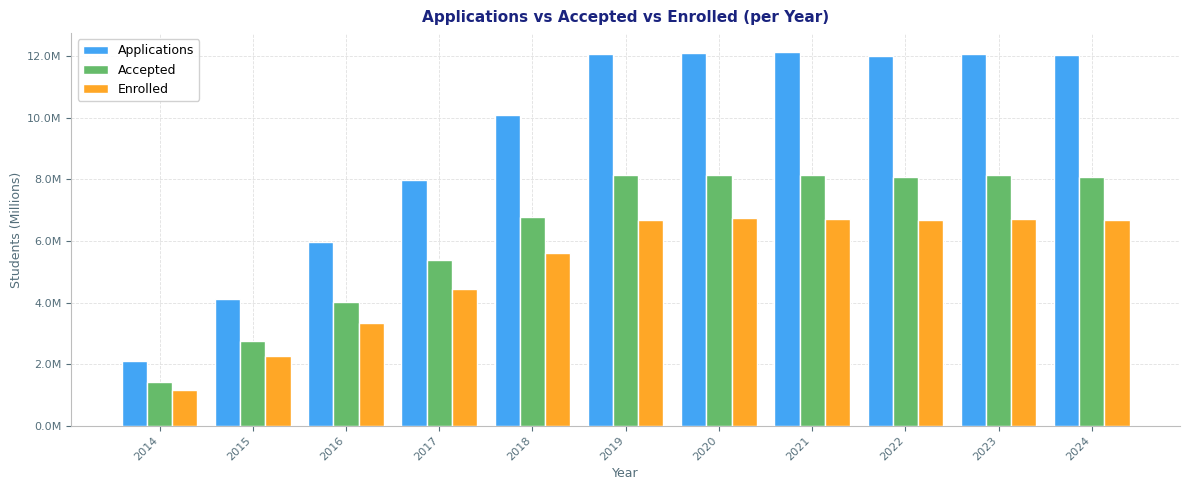

✅ Chart 2 saved: chart2_grouped_bar.png


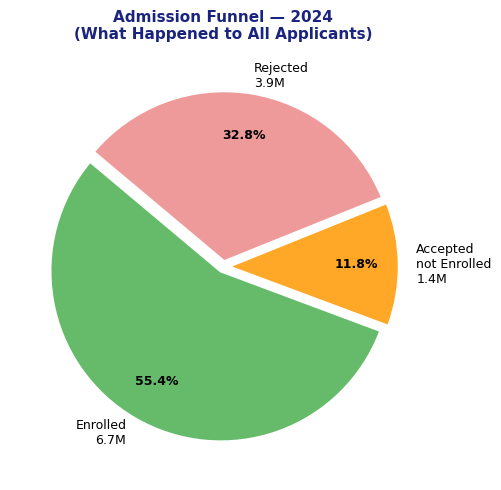

✅ Chart 3 saved: chart3_pie.png


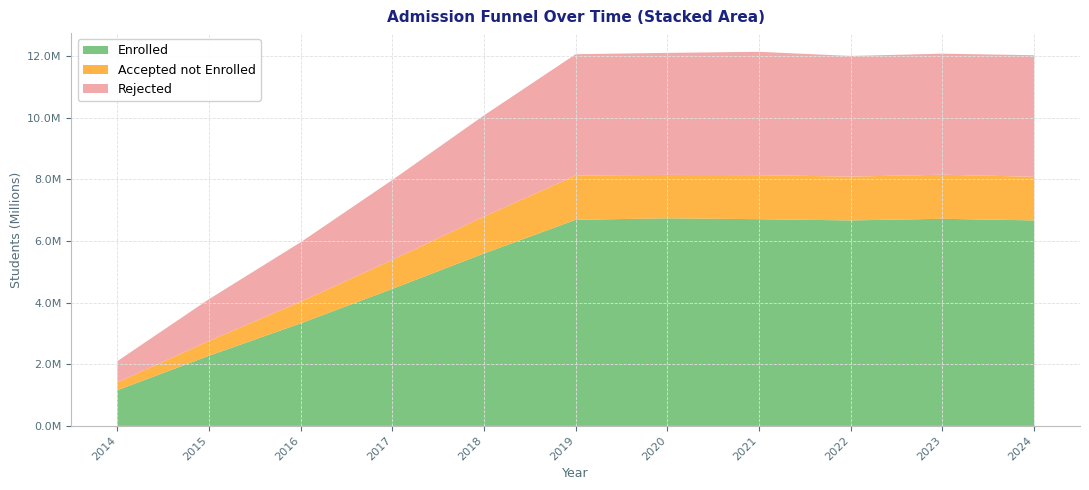

✅ Chart 4 saved: chart4_stacked_area.png


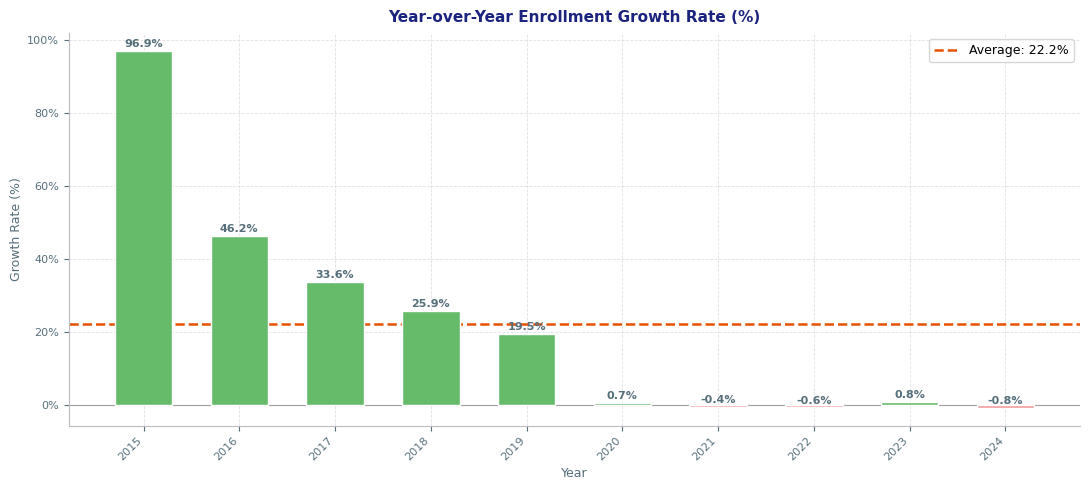

✅ Chart 5 saved: chart5_growth_rate.png


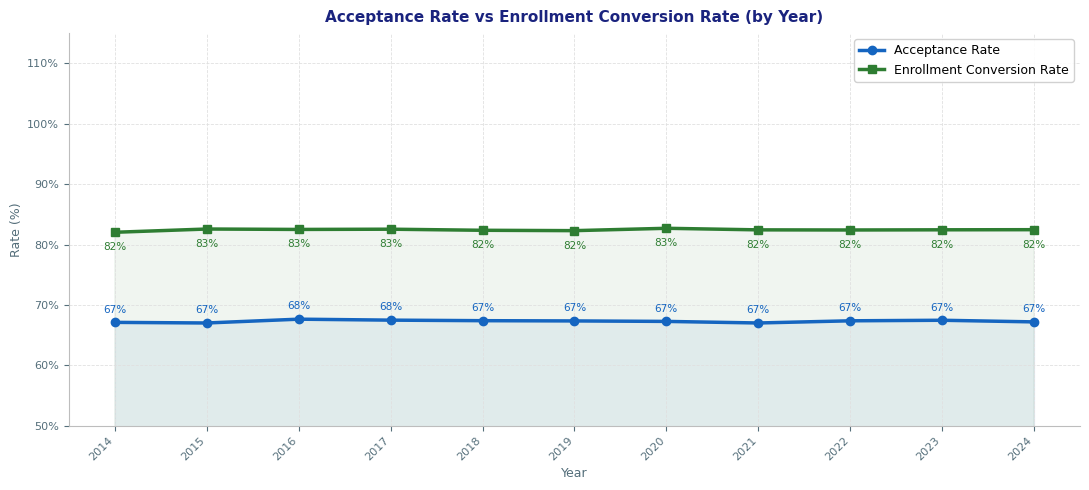

✅ Chart 6 saved: chart6_rates.png


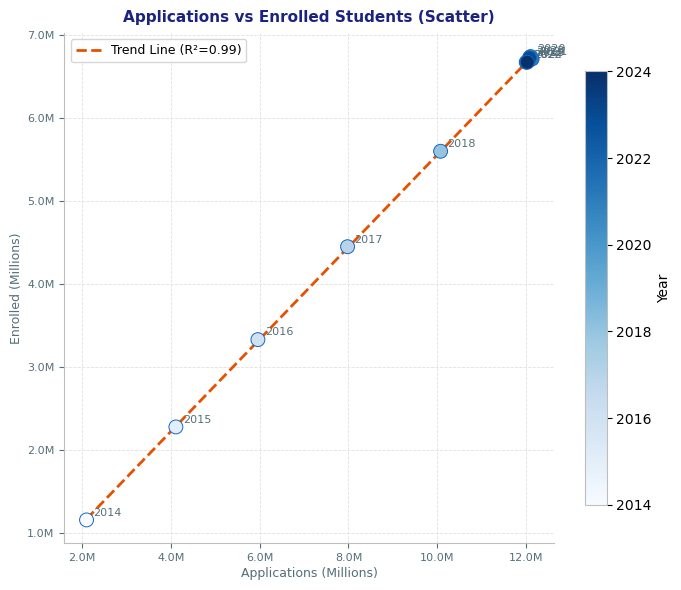

✅ Chart 7 saved: chart7_scatter.png

🎉 ALL 7 CHARTS COMPLETE!
Files saved in current directory:
  chart1_forecast_line.png
  chart2_grouped_bar.png
  chart3_pie.png
  chart4_stacked_area.png
  chart5_growth_rate.png
  chart6_rates.png
  chart7_scatter.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import numpy as np
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════
# SETUP — Style & Data
# ══════════════════════════════════════════════════════════════

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.facecolor'    : 'white',
    'figure.facecolor'  : 'white',
    'axes.grid'         : True,
    'grid.color'        : '#E0E0E0',
    'grid.linestyle'    : '--',
    'grid.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.edgecolor'    : '#BDBDBD',
})

BLUE   = '#1565C0'
LBLUE  = '#42A5F5'
GREEN  = '#2E7D32'
LGREEN = '#66BB6A'
ORANGE = '#E65100'
LORANG = '#FFA726'
DGREY  = '#546E7A'

def fmt_m(x, pos): return f'{x:.1f}M'
def fmt_p(x, pos): return f'{x:.0f}%'

def style_ax(ax, title, xlabel='Year', ylabel=''):
    ax.set_title(title, fontsize=11, fontweight='bold', color='#1A237E', pad=8)
    ax.set_xlabel(xlabel, fontsize=9, color=DGREY, labelpad=3)
    ax.set_ylabel(ylabel, fontsize=9, color=DGREY, labelpad=3)
    ax.tick_params(colors=DGREY, labelsize=8)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.grid(True, color='#E0E0E0', linestyle='--', linewidth=0.6)

# ── Derived columns ────────────────────────────────────────────
yearly_data["acceptance_rate_pct"] = (yearly_data["num_accepted"] / yearly_data["num_applications"] * 100).round(2)
yearly_data["enrollment_rate_pct"] = (yearly_data["num_enrolled"]  / yearly_data["num_accepted"]    * 100).round(2)

apps_m = yearly_data["num_applications"] / 1e6
acc_m  = yearly_data["num_accepted"]     / 1e6
enr_m  = yearly_data["num_enrolled"]     / 1e6
years  = yearly_data["year"].values

growth_clean = yearly_data["growth_rate"].dropna()
acc_rate     = yearly_data["acceptance_rate_pct"].values
enr_rate     = yearly_data["enrollment_rate_pct"].values

# ── Linear Regression + Forecast ──────────────────────────────
X_all       = years.reshape(-1, 1)
y_all       = yearly_data["num_enrolled"].values
model       = LinearRegression().fit(X_all, y_all)
y_pred_hist = model.predict(X_all)
residuals   = y_all - y_pred_hist

fut_years = np.array([2024, 2025, 2026, 2027, 2028, 2029, 2030])
y_fut     = model.predict(fut_years.reshape(-1, 1))
std_err   = np.std(residuals)
ci_upper  = y_fut + 1.96 * std_err
ci_lower  = y_fut - 1.96 * std_err


# ══════════════════════════════════════════════════════════════
# CHART 1 — Enrollment Trend & Forecast (Line Chart)
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(years, enr_m, color=BLUE, linewidth=2.5, marker='o',
        markersize=6, label='Historical Enrollment', zorder=5)
ax.plot(fut_years, y_fut/1e6, color=ORANGE, linewidth=2.5,
        marker='x', markersize=7, linestyle='--',
        label='Forecast 2025–2030', zorder=5)
ax.fill_between(years, enr_m, alpha=0.08, color=BLUE)
ax.fill_between(fut_years, ci_lower/1e6, ci_upper/1e6,
                alpha=0.12, color=ORANGE, label='95% Confidence Band')

# Label each forecast point
for x, y in zip(fut_years[1:], y_fut[1:]):
    ax.annotate(f'{y/1e6:.1f}M', (x, y/1e6),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=8, color=ORANGE, fontweight='bold')

ax.axvline(x=2024, color='#9E9E9E', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(2024.15, enr_m.min() + 0.3, '← History | Forecast →',
        fontsize=8, color='#757575', style='italic')

ax.yaxis.set_major_formatter(FuncFormatter(fmt_m))
all_years = np.append(years, fut_years[1:])
ax.set_xticks(all_years)
ax.set_xticklabels([str(y) for y in all_years], rotation=45, ha='right')
ax.legend(fontsize=9, framealpha=0.9, loc='upper left')
style_ax(ax, 'Nigeria School Enrollment: Historical Trend & 2025–2030 Forecast',
         ylabel='Enrolled Students (Millions)')

plt.tight_layout()
plt.savefig('chart1_forecast_line.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 1 saved: chart1_forecast_line.png")


# ══════════════════════════════════════════════════════════════
# CHART 2 — Applications vs Accepted vs Enrolled (Grouped Bar)
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(years))
w = 0.27
ax.bar(x - w, apps_m, w, color=LBLUE,  label='Applications', edgecolor='white', zorder=3)
ax.bar(x,     acc_m,  w, color=LGREEN, label='Accepted',     edgecolor='white', zorder=3)
ax.bar(x + w, enr_m,  w, color=LORANG, label='Enrolled',     edgecolor='white', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
ax.yaxis.set_major_formatter(FuncFormatter(fmt_m))
ax.legend(fontsize=9, framealpha=0.9)
style_ax(ax, 'Applications vs Accepted vs Enrolled (per Year)',
         ylabel='Students (Millions)')

plt.tight_layout()
plt.savefig('chart2_grouped_bar.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 2 saved: chart2_grouped_bar.png")


# ══════════════════════════════════════════════════════════════
# CHART 3 — Admission Funnel Pie Chart (Latest Year)
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(6, 5))

latest      = yearly_data.iloc[-1]
enr_val     = latest["num_enrolled"]
nacc_val    = latest["num_accepted"]  - latest["num_enrolled"]
rej_val     = latest["num_applications"] - latest["num_accepted"]
sizes       = [enr_val, nacc_val, rej_val]
pie_labels  = [f'Enrolled\n{enr_val/1e6:.1f}M',
               f'Accepted\nnot Enrolled\n{nacc_val/1e6:.1f}M',
               f'Rejected\n{rej_val/1e6:.1f}M']
pie_colors  = [LGREEN, LORANG, '#EF9A9A']

wedges, texts, autos = ax.pie(
    sizes, labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    explode=(0.03, 0.03, 0.03),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 9}
)
for at in autos:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax.set_title(f'Admission Funnel — {int(latest["year"])}\n(What Happened to All Applicants)',
             fontsize=11, fontweight='bold', color='#1A237E', pad=10)

plt.tight_layout()
plt.savefig('chart3_pie.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 3 saved: chart3_pie.png")


# ══════════════════════════════════════════════════════════════
# CHART 4 — Stacked Area (Funnel Over Time)
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11, 5))

rej_m  = (yearly_data["num_applications"] - yearly_data["num_accepted"]) / 1e6
nacc_m = (yearly_data["num_accepted"]     - yearly_data["num_enrolled"])  / 1e6

ax.stackplot(years, enr_m, nacc_m, rej_m,
             labels=['Enrolled', 'Accepted not Enrolled', 'Rejected'],
             colors=[LGREEN, LORANG, '#EF9A9A'], alpha=0.85)

ax.yaxis.set_major_formatter(FuncFormatter(fmt_m))
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
ax.legend(fontsize=9, framealpha=0.9, loc='upper left')
style_ax(ax, 'Admission Funnel Over Time (Stacked Area)',
         ylabel='Students (Millions)')

plt.tight_layout()
plt.savefig('chart4_stacked_area.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 4 saved: chart4_stacked_area.png")


# ══════════════════════════════════════════════════════════════
# CHART 5 — Year-over-Year Growth Rate (Bar)
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11, 5))

growth_vals  = growth_clean.values
growth_years = yearly_data.loc[yearly_data["growth_rate"].notna(), "year"].values
bar_colors   = [LGREEN if g >= 0 else '#EF9A9A' for g in growth_vals]

bars = ax.bar(growth_years, growth_vals, color=bar_colors,
              width=0.6, edgecolor='white', zorder=3)

for bar, val in zip(bars, growth_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=8, color=DGREY, fontweight='bold')

ax.axhline(0, color='#9E9E9E', linewidth=0.8)
ax.axhline(np.mean(growth_vals), color=ORANGE, linewidth=1.8,
           linestyle='--', label=f'Average: {np.mean(growth_vals):.1f}%')

ax.yaxis.set_major_formatter(FuncFormatter(fmt_p))
ax.set_xticks(growth_years)
ax.set_xticklabels([str(y) for y in growth_years], rotation=45, ha='right')
ax.legend(fontsize=9)
style_ax(ax, 'Year-over-Year Enrollment Growth Rate (%)',
         ylabel='Growth Rate (%)')

plt.tight_layout()
plt.savefig('chart5_growth_rate.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 5 saved: chart5_growth_rate.png")


# ══════════════════════════════════════════════════════════════
# CHART 6 — Acceptance Rate vs Enrollment Conversion Rate
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(years, acc_rate, color=BLUE,  linewidth=2.5, marker='o',
        markersize=6, label='Acceptance Rate')
ax.plot(years, enr_rate, color=GREEN, linewidth=2.5, marker='s',
        markersize=6, label='Enrollment Conversion Rate')
ax.fill_between(years, acc_rate, alpha=0.07, color=BLUE)
ax.fill_between(years, enr_rate, alpha=0.07, color=GREEN)

for yr, ar, er in zip(years, acc_rate, enr_rate):
    ax.annotate(f'{ar:.0f}%', (yr, ar),
                textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=7.5, color=BLUE)
    ax.annotate(f'{er:.0f}%', (yr, er),
                textcoords='offset points', xytext=(0, -13),
                ha='center', fontsize=7.5, color=GREEN)

ax.set_ylim(50, 115)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_p))
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
ax.legend(fontsize=9, framealpha=0.9)
style_ax(ax, 'Acceptance Rate vs Enrollment Conversion Rate (by Year)',
         ylabel='Rate (%)')

plt.tight_layout()
plt.savefig('chart6_rates.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 6 saved: chart6_rates.png")


# ══════════════════════════════════════════════════════════════
# CHART 7 — Scatter Plot: Applications vs Enrolled
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(apps_m, enr_m, c=years, cmap='Blues',
                s=100, zorder=5, edgecolors=BLUE, linewidth=0.7)

# Trend line
m_coef = np.polyfit(apps_m, enr_m, 1)
x_line = np.linspace(apps_m.min(), apps_m.max(), 100)
ax.plot(x_line, np.polyval(m_coef, x_line),
        color=ORANGE, linewidth=2, linestyle='--', label='Trend Line (R²=0.99)')

for i, yr in enumerate(years):
    ax.annotate(str(yr), (apps_m.iloc[i], enr_m.iloc[i]),
                textcoords='offset points', xytext=(5, 3),
                fontsize=8, color=DGREY)

plt.colorbar(sc, ax=ax, label='Year', shrink=0.85)
ax.xaxis.set_major_formatter(FuncFormatter(fmt_m))
ax.yaxis.set_major_formatter(FuncFormatter(fmt_m))
ax.legend(fontsize=9)
style_ax(ax, 'Applications vs Enrolled Students (Scatter)',
         xlabel='Applications (Millions)', ylabel='Enrolled (Millions)')

plt.tight_layout()
plt.savefig('chart7_scatter.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 7 saved: chart7_scatter.png")


print("\n🎉 ALL 7 CHARTS COMPLETE!")
print("Files saved in current directory:")
print("  chart1_forecast_line.png")
print("  chart2_grouped_bar.png")
print("  chart3_pie.png")
print("  chart4_stacked_area.png")
print("  chart5_growth_rate.png")
print("  chart6_rates.png")
print("  chart7_scatter.png")